# Exploratory Data Analysis

## Section 1 — Imports & Load

In [ ]:
import math
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import (
    MinMaxScaler,
)  # Note: Imported strictly for EDA visualization, not pipeline preprocessing

# 1. Set Seaborn visual style
sns.set_theme(style="whitegrid")

# 2. Set Matplotlib figure defaults
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 100,
        "axes.titlesize": 16,
        "axes.labelsize": 12,
    }
)

# 3. Set Random Seed Generator for numpy
SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
df = pd.read_csv("../data/raw/multimodal_sports_injury_dataset.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(r"[\s\-]+", "_", regex=True)

In [3]:
print(f"Shape: {df.shape}")
print(f"Column list: {df.columns.to_list()}")

Shape: (15420, 29)
Column list: ['athlete_id', 'heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity', 'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height', 'ground_reaction_force', 'range_of_motion', 'ambient_temperature', 'humidity', 'altitude', 'playing_surface', 'training_intensity', 'training_duration', 'training_load', 'fatigue_index', 'injury_occurred', 'session_id', 'sport_type', 'gender', 'age', 'bmi']


In [4]:
print("Info and dtypes:")
df.info()

Info and dtypes:
<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   athlete_id             15420 non-null  int64  
 1   heart_rate             15066 non-null  float64
 2   body_temperature       15420 non-null  float64
 3   hydration_level        15035 non-null  float64
 4   sleep_quality          14927 non-null  float64
 5   recovery_score         15420 non-null  float64
 6   stress_level           15420 non-null  float64
 7   muscle_activity        14850 non-null  float64
 8   joint_angles           15420 non-null  float64
 9   gait_speed             14989 non-null  float64
 10  cadence                15420 non-null  float64
 11  step_count             15420 non-null  int64  
 12  jump_height            15420 non-null  float64
 13  ground_reaction_force  15420 non-null  float64
 14  range_of_motion        15420 non-null  float64
 

## Section 2 — First Look

In [5]:
print("Dataset:")
display(df.head(10))
display(df.tail())

Dataset:


,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
0,1,NaN,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,5.678475,79.106564,548.417962,45.028687,0,1,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,NaN,116.954654,538.043815,42.254717,2,2,Basketball,Female,18,25.105748
2,1,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,6.643242,96.354742,647.784339,61.870056,0,3,Basketball,Female,18,25.105748
3,1,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,6.194427,97.619130,336.553431,50.268845,0,4,Basketball,Female,18,25.105748
4,1,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,5.835804,83.155527,496.076352,29.233575,2,5,Basketball,Female,18,25.105748
5,1,70.754096,37.534470,57.572197,5.776244,42.941389,0.397134,597.625695,89.546268,1.761310,...,6.228434,94.102408,684.401046,61.556005,0,6,Basketball,Female,18,25.105748
6,1,78.016619,37.348621,100.000000,8.269259,81.132152,0.298191,128.615766,87.890744,0.819571,...,9.341229,128.086103,1081.065295,82.093050,1,7,Basketball,Female,18,25.105748
7,1,72.560307,36.650910,89.539244,7.308155,57.739198,0.549367,629.597044,175.000000,1.965504,...,5.242513,86.924184,470.069442,39.870280,0,8,Basketball,Female,18,25.105748
8,1,78.672957,36.824125,96.283096,NaN,77.911384,0.346742,230.434284,110.915011,2.595353,...,6.751030,92.593812,826.062286,60.017669,0,9,Basketball,Female,18,25.105748
9,1,46.843844,37.308826,72.440492,6.243913,52.700225,0.488558,218.296355,86.817703,1.720865,...,5.702790,72.822765,357.580668,58.313706,0,10,Basketball,Female,18,25.105748


,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
15415,84,69.956860,37.214621,69.544088,4.418336,38.957484,0.239706,NaN,127.835085,NaN,...,7.038863,63.341808,627.752431,52.845054,0,100,Basketball,Female,26,20.145185
15416,18,70.785554,36.927019,84.422453,3.976723,34.893546,0.472006,263.783492,128.887289,NaN,...,5.504547,81.735077,1001.613854,67.373233,2,100,Track,Female,24,21.309957
15417,141,108.757968,36.875496,76.679104,4.552625,39.487996,0.628583,333.898593,157.497212,2.176849,...,7.794103,106.064377,767.130093,76.089216,1,100,Basketball,Male,23,28.098897
15418,113,65.489580,37.343535,60.761053,3.877293,39.956892,0.664920,320.438215,123.040641,2.342617,...,5.703675,108.543899,793.033403,76.804070,0,99,Track,Female,34,22.719505
15419,104,74.626714,37.655866,84.914838,6.983385,57.556650,0.110859,342.670254,114.384445,1.973143,...,5.124721,70.760267,445.392873,48.225571,2,100,Soccer,Male,18,24.617367


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.to_list()
categorical_cols = df.select_dtypes(exclude=np.number).columns.to_list()

In [7]:
display(df[numeric_cols].describe())
display(df[categorical_cols].value_counts())

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,altitude,playing_surface,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,age,bmi
count,15420.000000,15066.000000,15420.000000,15035.000000,14927.000000,15420.000000,15420.000000,14850.000000,15420.000000,14989.000000,...,15420.000000,15420.000000,14788.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,78.547601,72.688277,37.106443,78.036991,5.817429,55.202220,0.422916,247.724105,112.464607,1.864699,...,297.357416,2.019326,6.399174,87.790419,670.534269,59.698315,0.510117,49.926719,23.953567,23.138679
std,45.070131,17.758991,0.594843,11.848363,1.814602,17.326338,0.173425,126.930007,30.367148,0.603927,...,212.351977,1.409120,1.730882,27.628191,328.288466,25.196238,0.741662,28.540223,3.883533,2.301192
min,1.000000,40.000000,35.800000,45.000000,1.155807,8.902584,0.100000,10.000000,45.000000,0.800000,...,0.000000,0.000000,2.000000,30.000000,150.000000,15.000000,0.000000,1.000000,18.000000,18.500000
25%,39.000000,60.097967,36.698612,69.879145,4.510581,42.321722,0.300472,159.150375,91.437246,1.430372,...,127.750679,1.000000,5.208488,68.768634,426.148857,41.717110,0.000000,25.000000,21.000000,21.609635
50%,79.000000,72.304051,37.107090,78.165927,5.755650,54.421403,0.421168,245.496682,112.548535,1.854269,...,284.172663,2.000000,6.411926,87.835380,645.225337,57.340187,0.000000,50.000000,24.000000,22.988013
75%,118.000000,84.812895,37.512165,86.498440,7.068894,67.375690,0.543678,334.039698,133.960070,2.281691,...,442.388486,3.000000,7.597567,106.696365,879.607967,75.186924,1.000000,75.000000,27.000000,24.817666
max,156.000000,159.270125,39.200000,100.000000,10.000000,98.000000,0.950000,722.542819,175.000000,3.500000,...,1200.000000,4.000000,10.000000,180.000000,2632.637547,270.193219,2.000000,101.000000,34.000000,28.300000


sport_type  gender
Track       Male      3156
Soccer      Male      2865
Basketball  Male      2775
Soccer      Female    1972
Other       Female    1384
Basketball  Female    1284
Other       Male       993
Track       Female     991
Name: count, dtype: int64

playing_surface should be a categorical nominal column, will fix that in preprocessing.

## Section 3 — Missing Value Audit

In [ ]:
null_counts = df.isnull().sum()

null_percentages = (df.isnull().sum() / len(df)) * 100

null_summary = pd.DataFrame(
    {"Null Count": null_counts, "Percentage (%)": null_percentages}
)

null_summary = null_summary[null_summary["Null Count"] > 0].sort_values(
    by="Null Count", ascending=False
)

print("Columns with missing values:")
display(null_summary)

Columns with missing values:


,Null Count,Percentage (%)
training_intensity,632,4.098573
muscle_activity,570,3.696498
sleep_quality,493,3.197147
gait_speed,431,2.795071
hydration_level,385,2.496757
heart_rate,354,2.295720


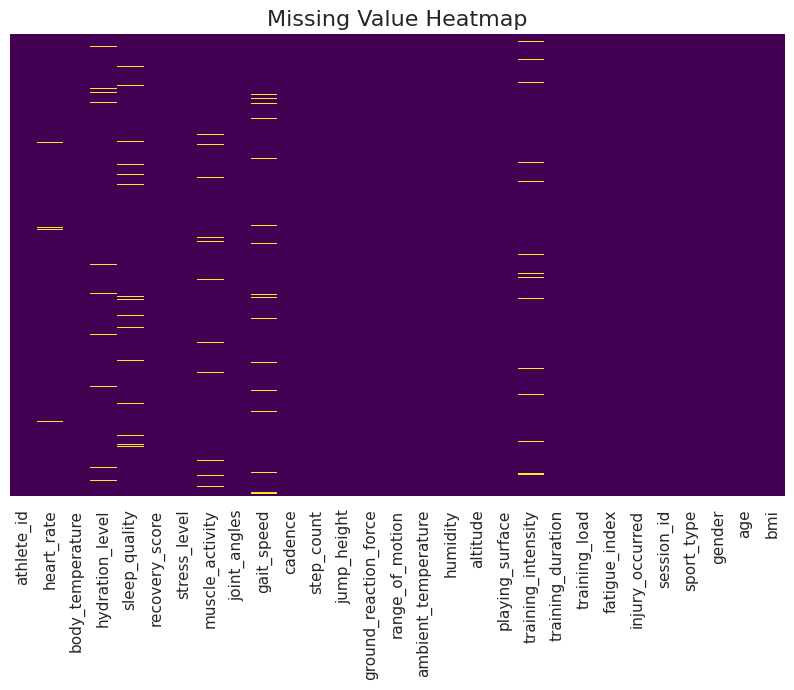

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap", fontsize=16)
plt.show()

In [ ]:
null_cols = df.columns[df.isnull().any()].to_list()
null_counts = df.groupby("injury_occurred")[null_cols].apply(lambda x: x.isnull().sum())
class_totals = df["injury_occurred"].value_counts().sort_index()

null_percentages = (null_counts.T / class_totals.values * 100).T

print("Percentage of nulls per class:")
display(null_percentages)

Percentage of nulls per class:


,heart_rate,hydration_level,sleep_quality,muscle_activity,gait_speed,training_intensity
injury_occurred,,,,,,
0,2.219295,2.543575,3.111066,3.698824,2.665180,4.094041
1,2.038295,2.347128,3.613342,3.705991,2.686844,4.045707
2,2.981850,2.506482,2.981850,3.673293,3.500432,4.191876


Conclusion: The missing values appear to be uniformly distributed.

## Section 4 — Target Variable Analysis

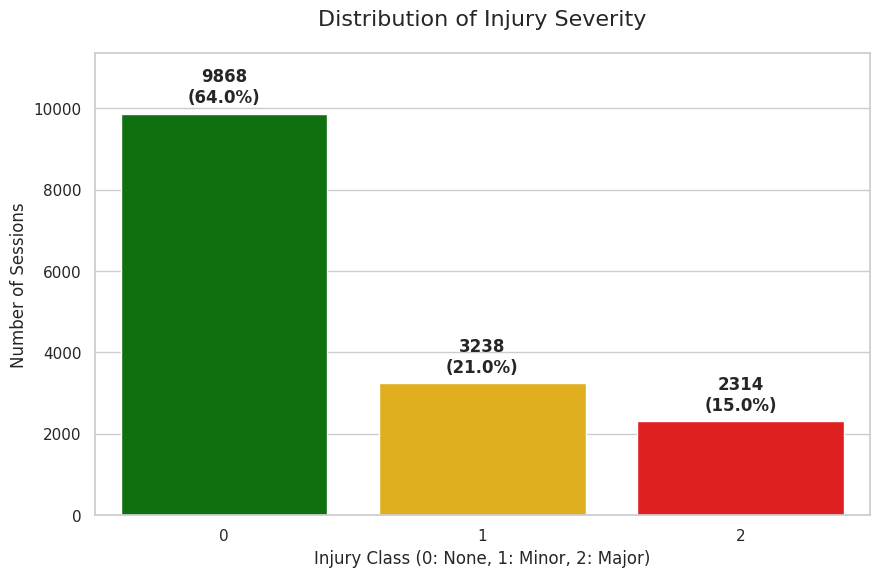

In [ ]:
percentages = (class_totals / len(df)) * 100

colors = ["green", "#FFBF00", "red"]

ax = sns.barplot(
    x=class_totals.index,
    y=class_totals.values,
    palette=colors,
    hue=class_totals.index,
    legend=False,
)

for i, p in enumerate(ax.patches):
    count = class_totals.iloc[i]
    pct = percentages.iloc[i]

    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    ax.annotate(
        f"{count}\n({pct:.1f}%)",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.title("Distribution of Injury Severity", fontsize=16, pad=20)
plt.xlabel("Injury Class (0: None, 1: Minor, 2: Major)", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.ylim(0, max(class_totals) * 1.15)

plt.show()

In [12]:
imbalance_ratio = class_totals[0] / class_totals[2]

print(f"Count of Class 0: {class_totals[0]}")
print(f"Count of Class 2: {class_totals[2]}")
print(f"Imbalance Ratio (Class 0 / Class 2): {imbalance_ratio:.2f}:1")

Count of Class 0: 9868
Count of Class 2: 2314
Imbalance Ratio (Class 0 / Class 2): 4.26:1


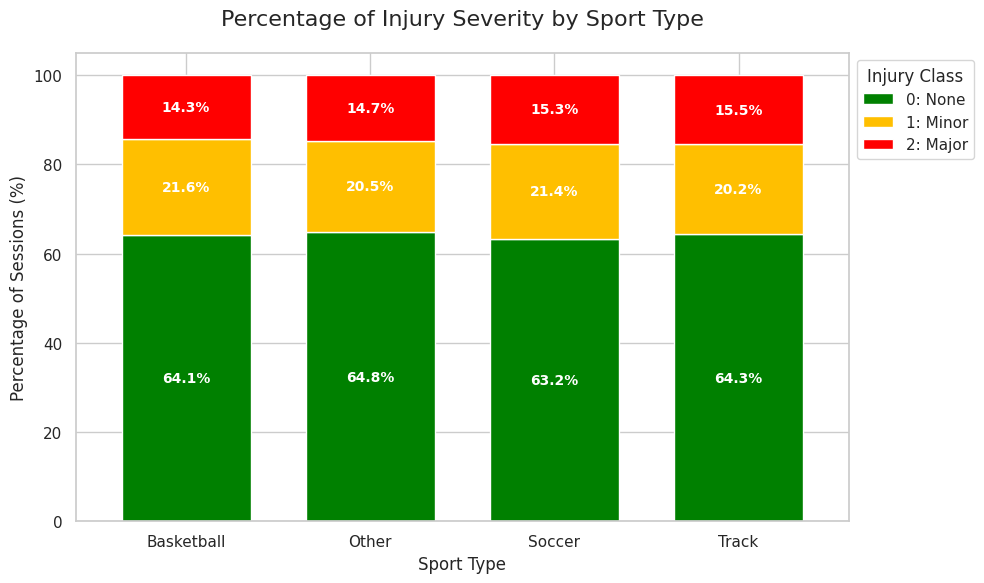

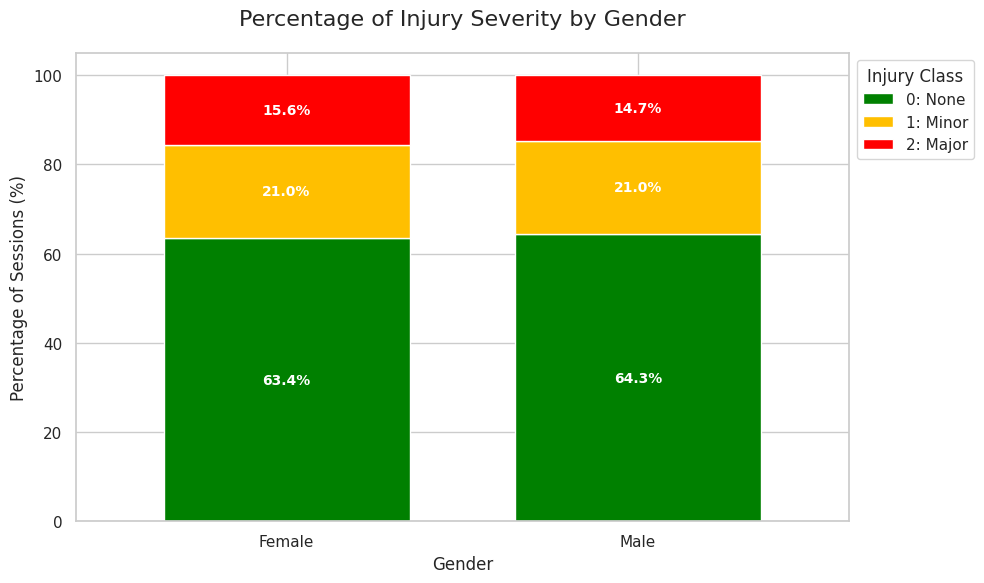

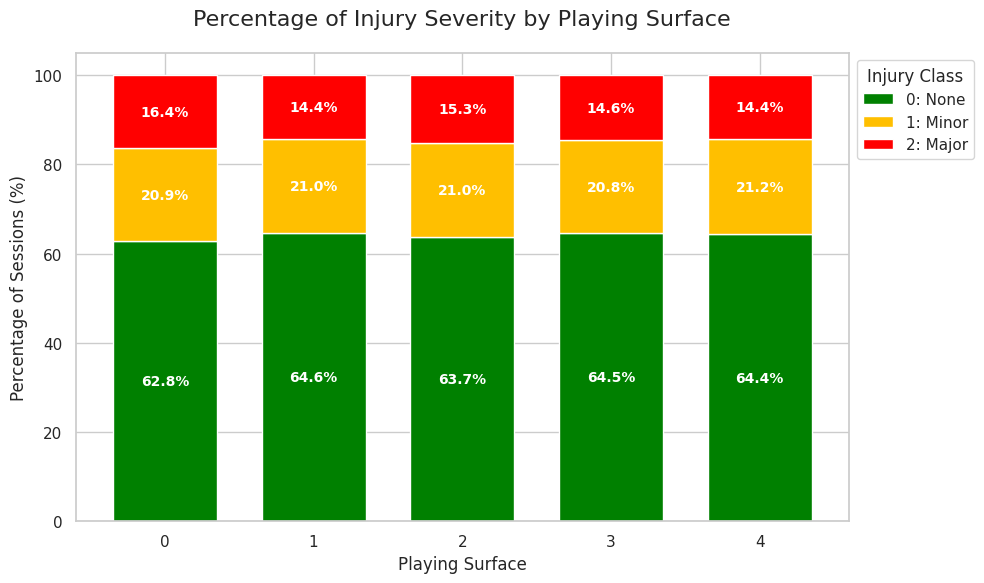

In [ ]:
def plot_categorical_injury_risk(data, cat_col, target_col="injury_occurred"):
    ct_pct = pd.crosstab(data[cat_col], data[target_col], normalize="index") * 100

    colors = ["green", "#FFBF00", "red"]
    ax = ct_pct.plot(kind="bar", stacked=True, color=colors, width=0.7)

    plt.title(
        f'Percentage of Injury Severity by {cat_col.replace("_", " ").title()}', pad=20
    )
    plt.xlabel(cat_col.replace("_", " ").title())
    plt.ylabel("Percentage of Sessions (%)")
    plt.xticks(rotation=0)
    plt.legend(
        title="Injury Class",
        labels=["0: None", "1: Minor", "2: Major"],
        loc="upper left",
        bbox_to_anchor=(1, 1),
    )

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5:
            x, y = p.get_xy()
            ax.annotate(
                f"{height:.1f}%",
                (x + width / 2, y + height / 2),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="white",
            )

    plt.tight_layout()
    plt.show()


plot_categorical_injury_risk(df, "sport_type")
plot_categorical_injury_risk(df, "gender")
plot_categorical_injury_risk(df, "playing_surface")

## Section 5 — Feature Distributions

In [ ]:
physiological = [
    "heart_rate",
    "body_temperature",
    "hydration_level",
    "sleep_quality",
    "recovery_score",
    "stress_level",
]

biomechanical = [
    "muscle_activity",
    "joint_angles",
    "gait_speed",
    "cadence",
    "step_count",
    "jump_height",
    "ground_reaction_force",
    "range_of_motion",
]

environmental = ["ambient_temperature", "humidity", "altitude", "playing_surface"]

workload = ["training_intensity", "training_duration", "training_load", "fatigue_index"]

athlete_profile = ["age", "bmi"]

target = "injury_occurred"
metadata = ["athlete_id", "session_id", "sport_type", "gender"]

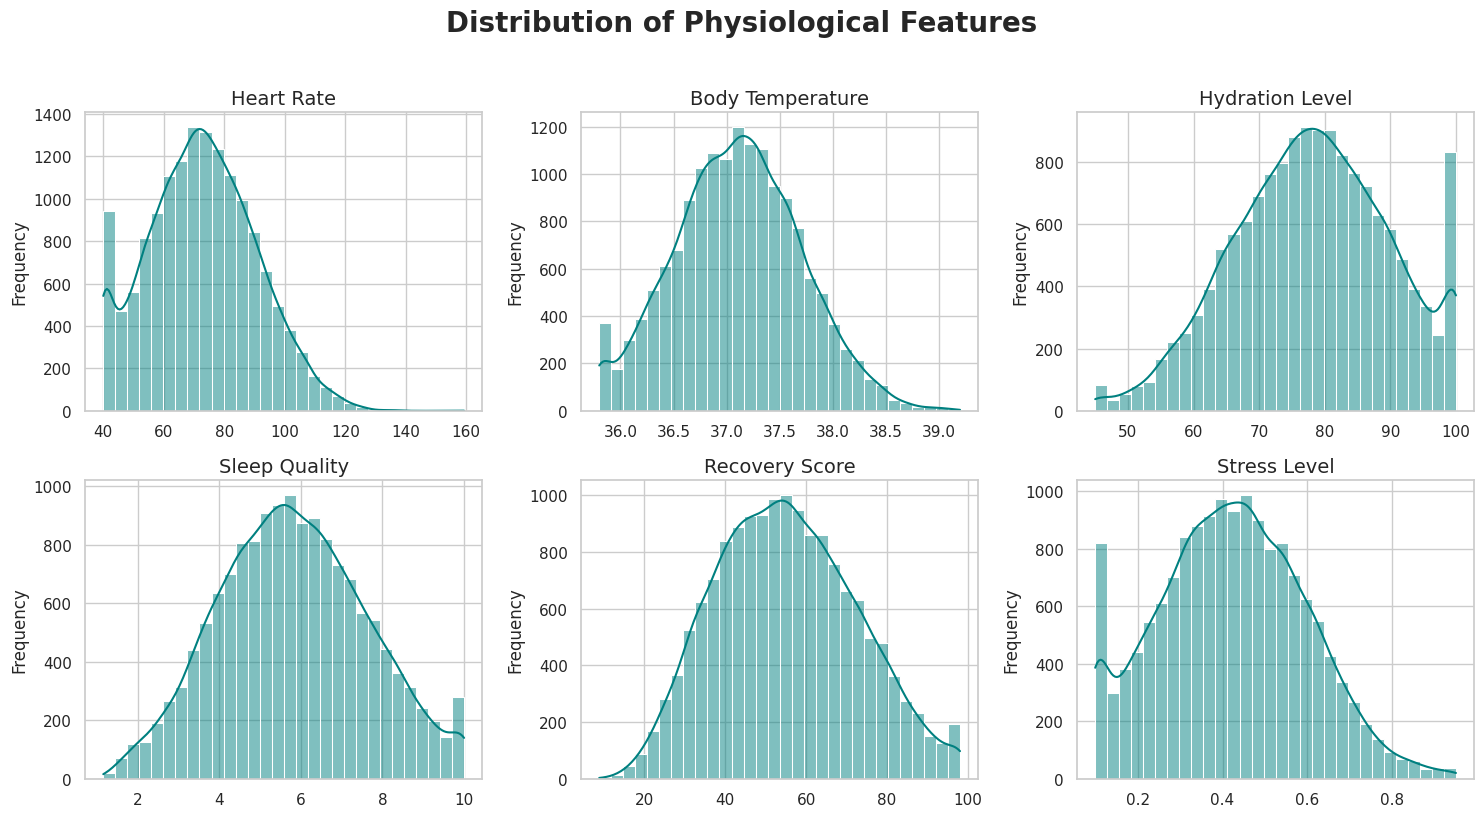

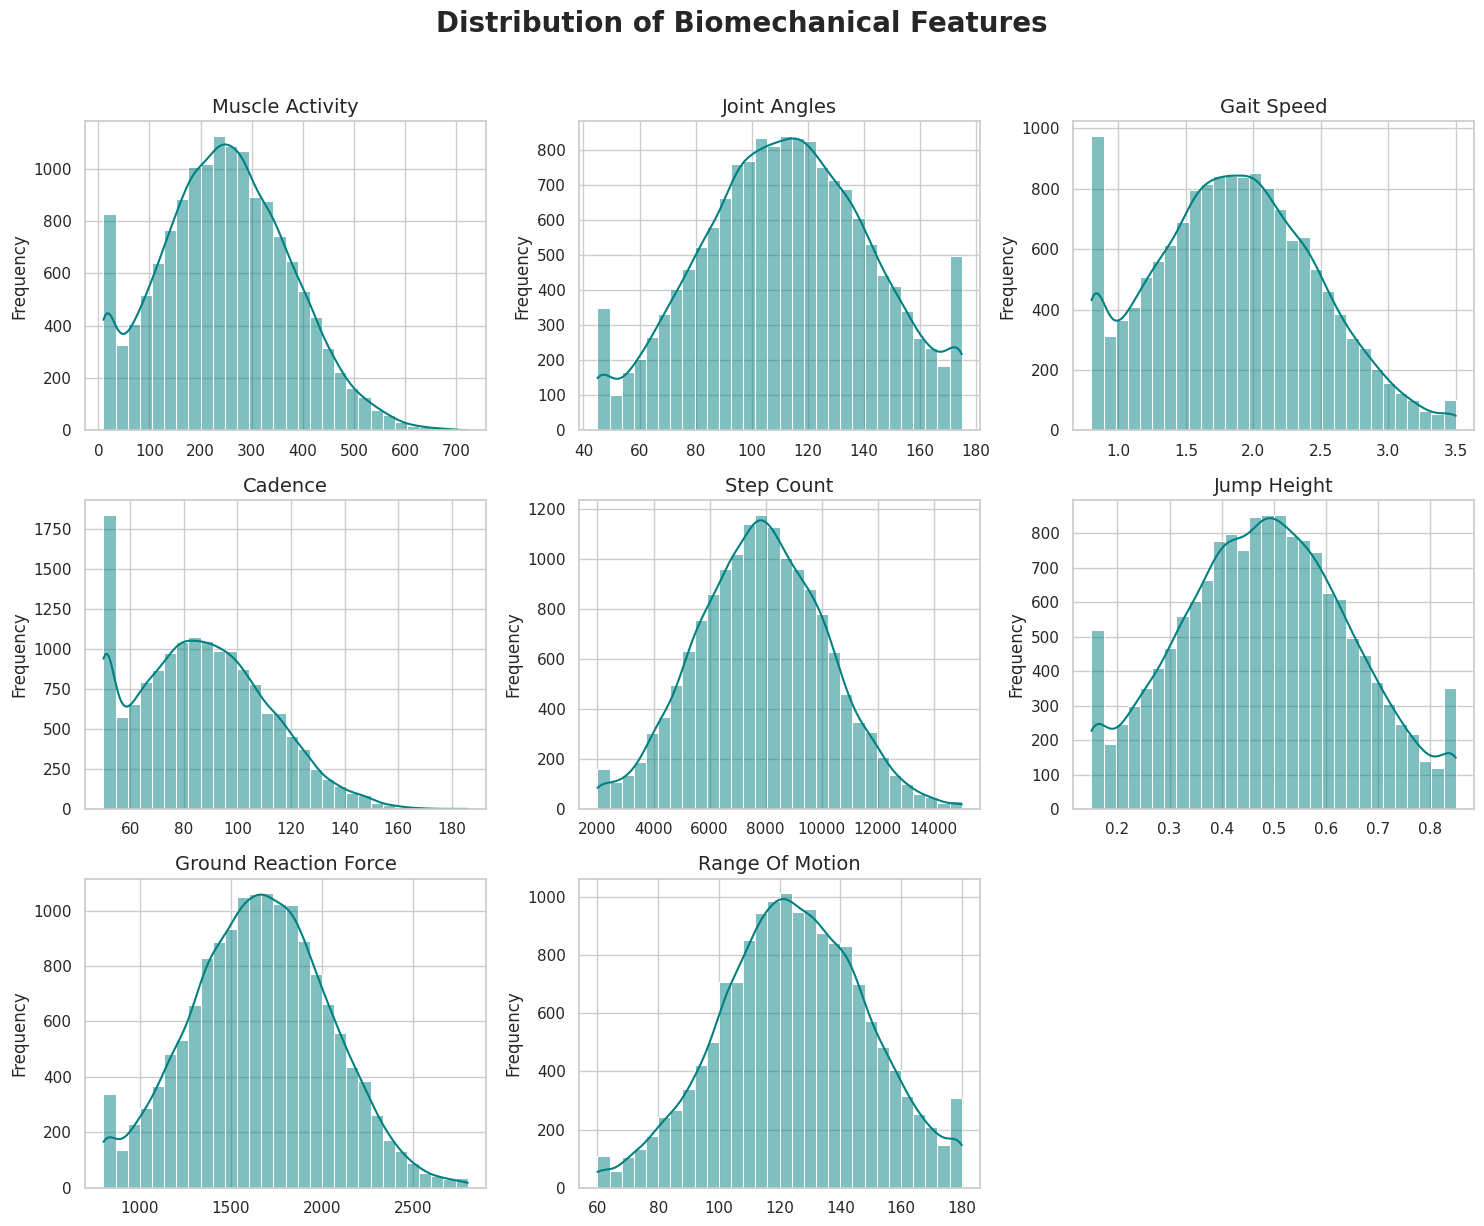

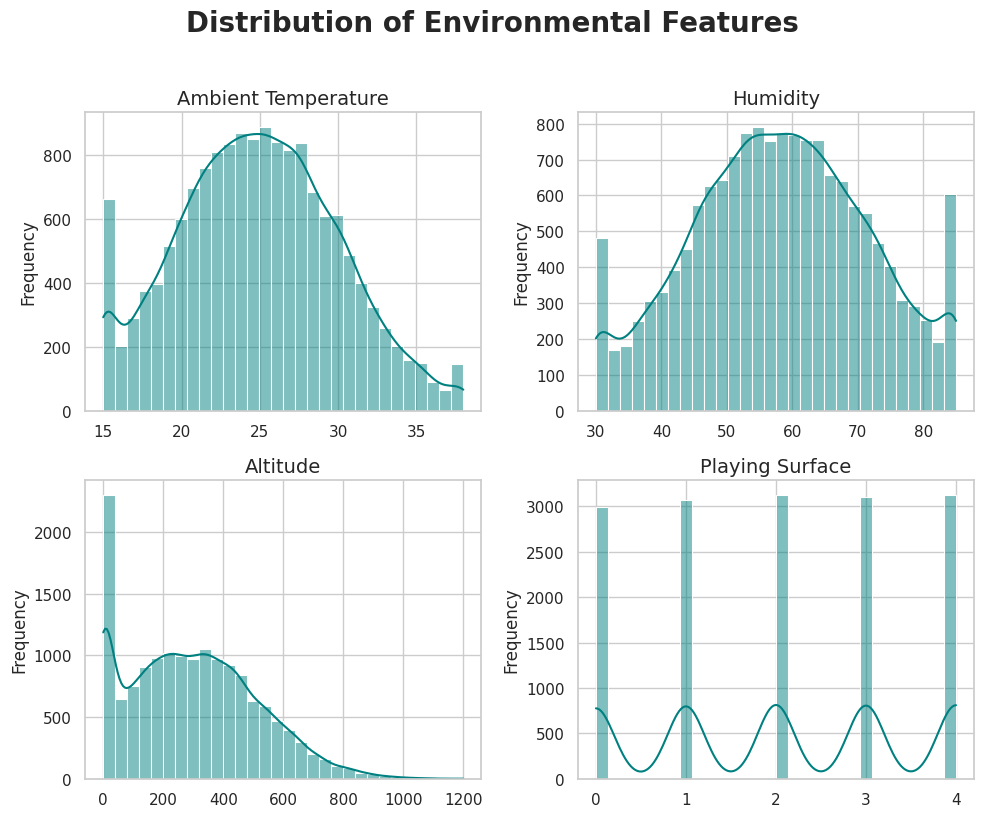

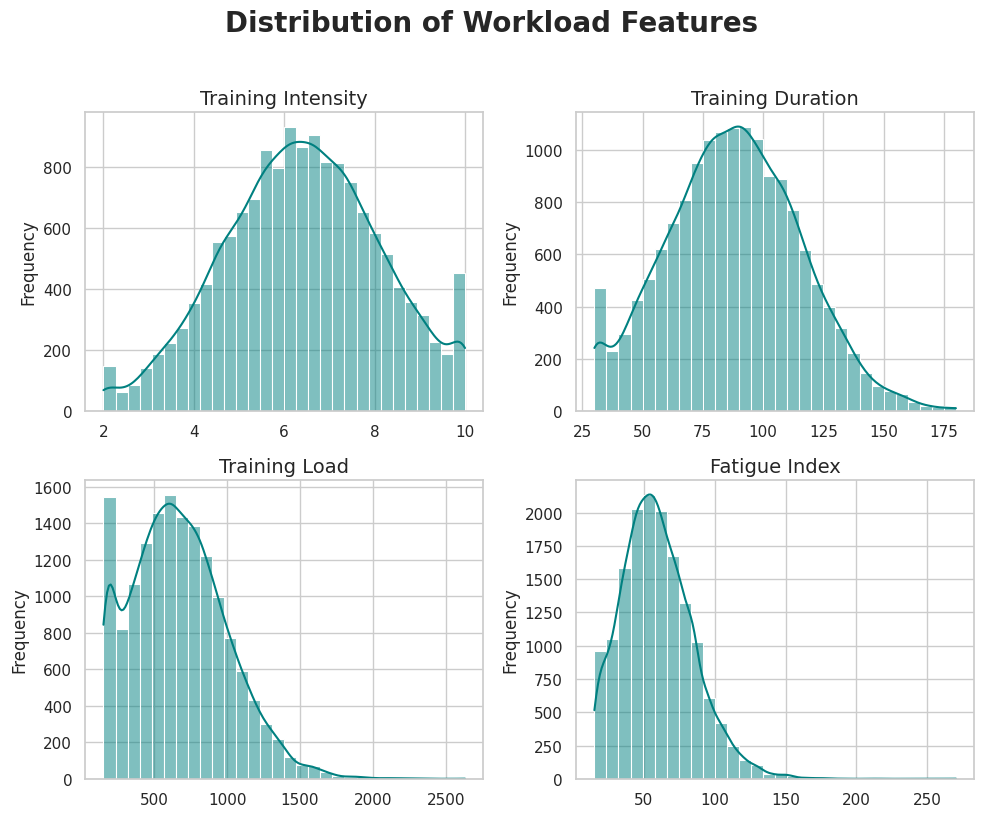

In [ ]:
feature_groups = {
    "Physiological": physiological,
    "Biomechanical": biomechanical,
    "Environmental": environmental,
    "Workload": workload,
}

for group_name, features in feature_groups.items():
    ncols = 2 if len(features) <= 4 else 3
    nrows = math.ceil(len(features) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    fig.suptitle(
        f"Distribution of {group_name} Features", fontsize=20, fontweight="bold", y=1.02
    )

    axes_flat = axes.flatten()

    for i, col in enumerate(features):
        sns.histplot(df[col], kde=True, ax=axes_flat[i], color="teal", bins=30)
        axes_flat[i].set_title(f'{col.replace("_", " ").title()}', fontsize=14)
        axes_flat[i].set_xlabel("")
        axes_flat[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()

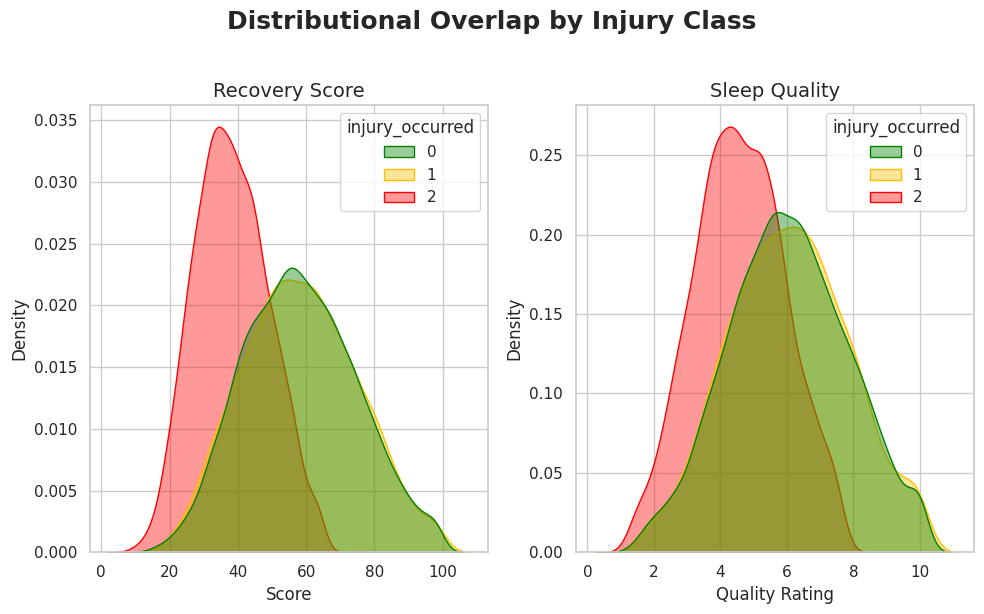

In [ ]:
fig, axes = plt.subplots(1, 2)
fig.suptitle(
    "Distributional Overlap by Injury Class", fontsize=18, fontweight="bold", y=1.02
)

injury_palette = {0: "green", 1: "#FFBF00", 2: "red"}

sns.kdeplot(
    data=df,
    x="recovery_score",
    hue="injury_occurred",
    fill=True,
    palette=injury_palette,
    alpha=0.4,
    ax=axes[0],
    common_norm=False,
)
axes[0].set_title("Recovery Score", fontsize=14)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")

sns.kdeplot(
    data=df,
    x="sleep_quality",
    hue="injury_occurred",
    fill=True,
    palette=injury_palette,
    alpha=0.4,
    ax=axes[1],
    common_norm=False,
)
axes[1].set_title("Sleep Quality", fontsize=14)
axes[1].set_xlabel("Quality Rating")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

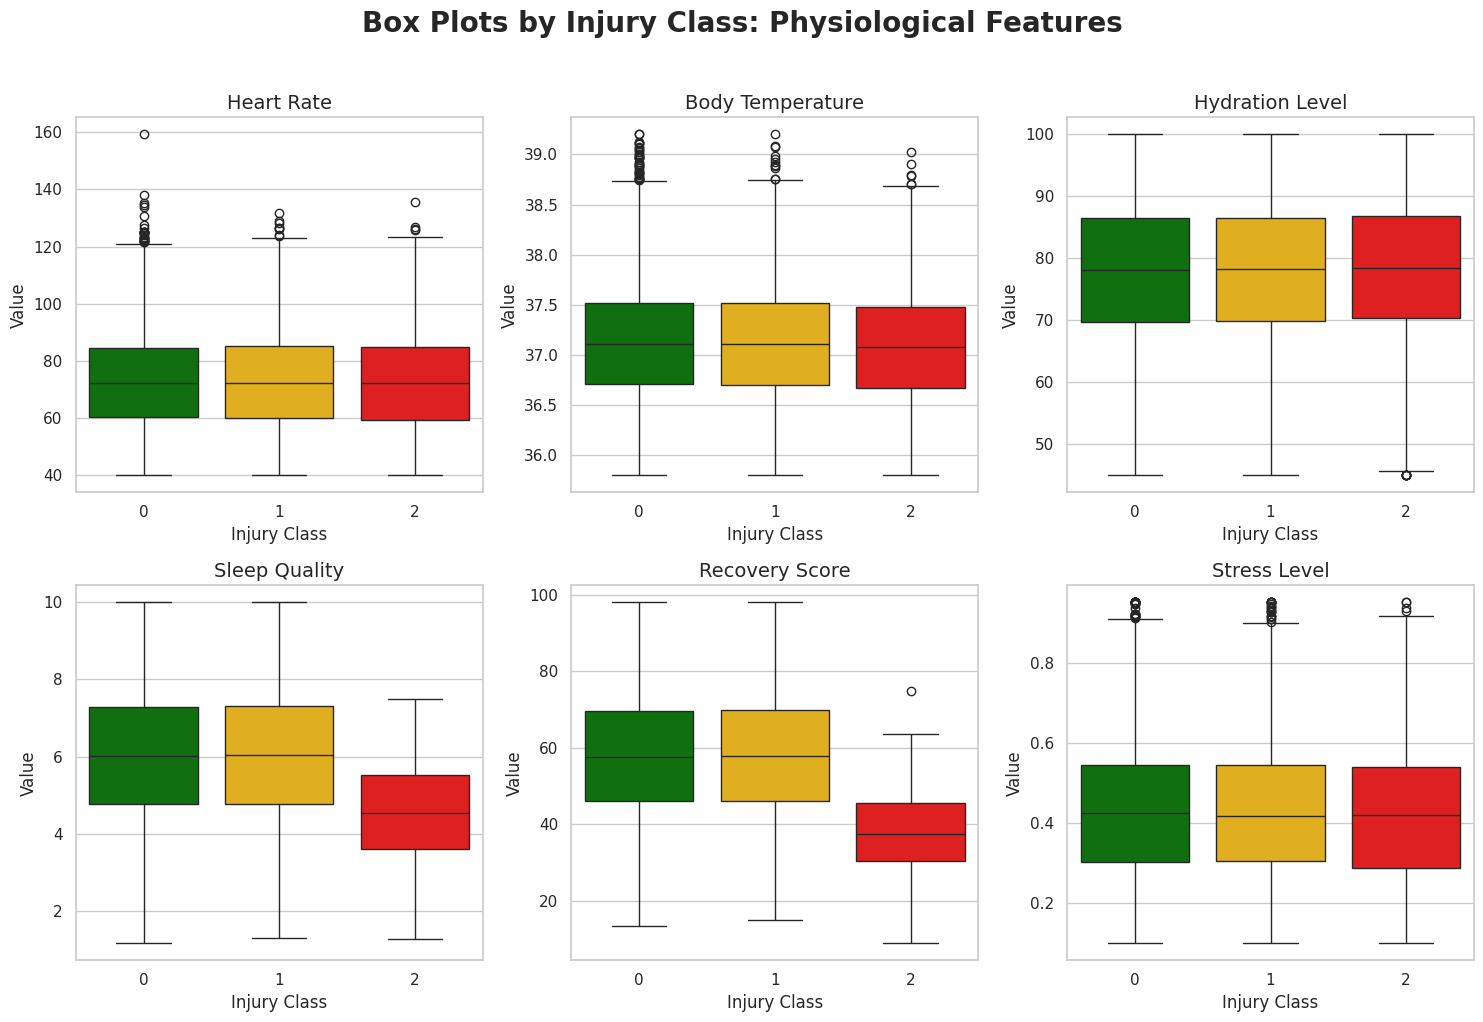

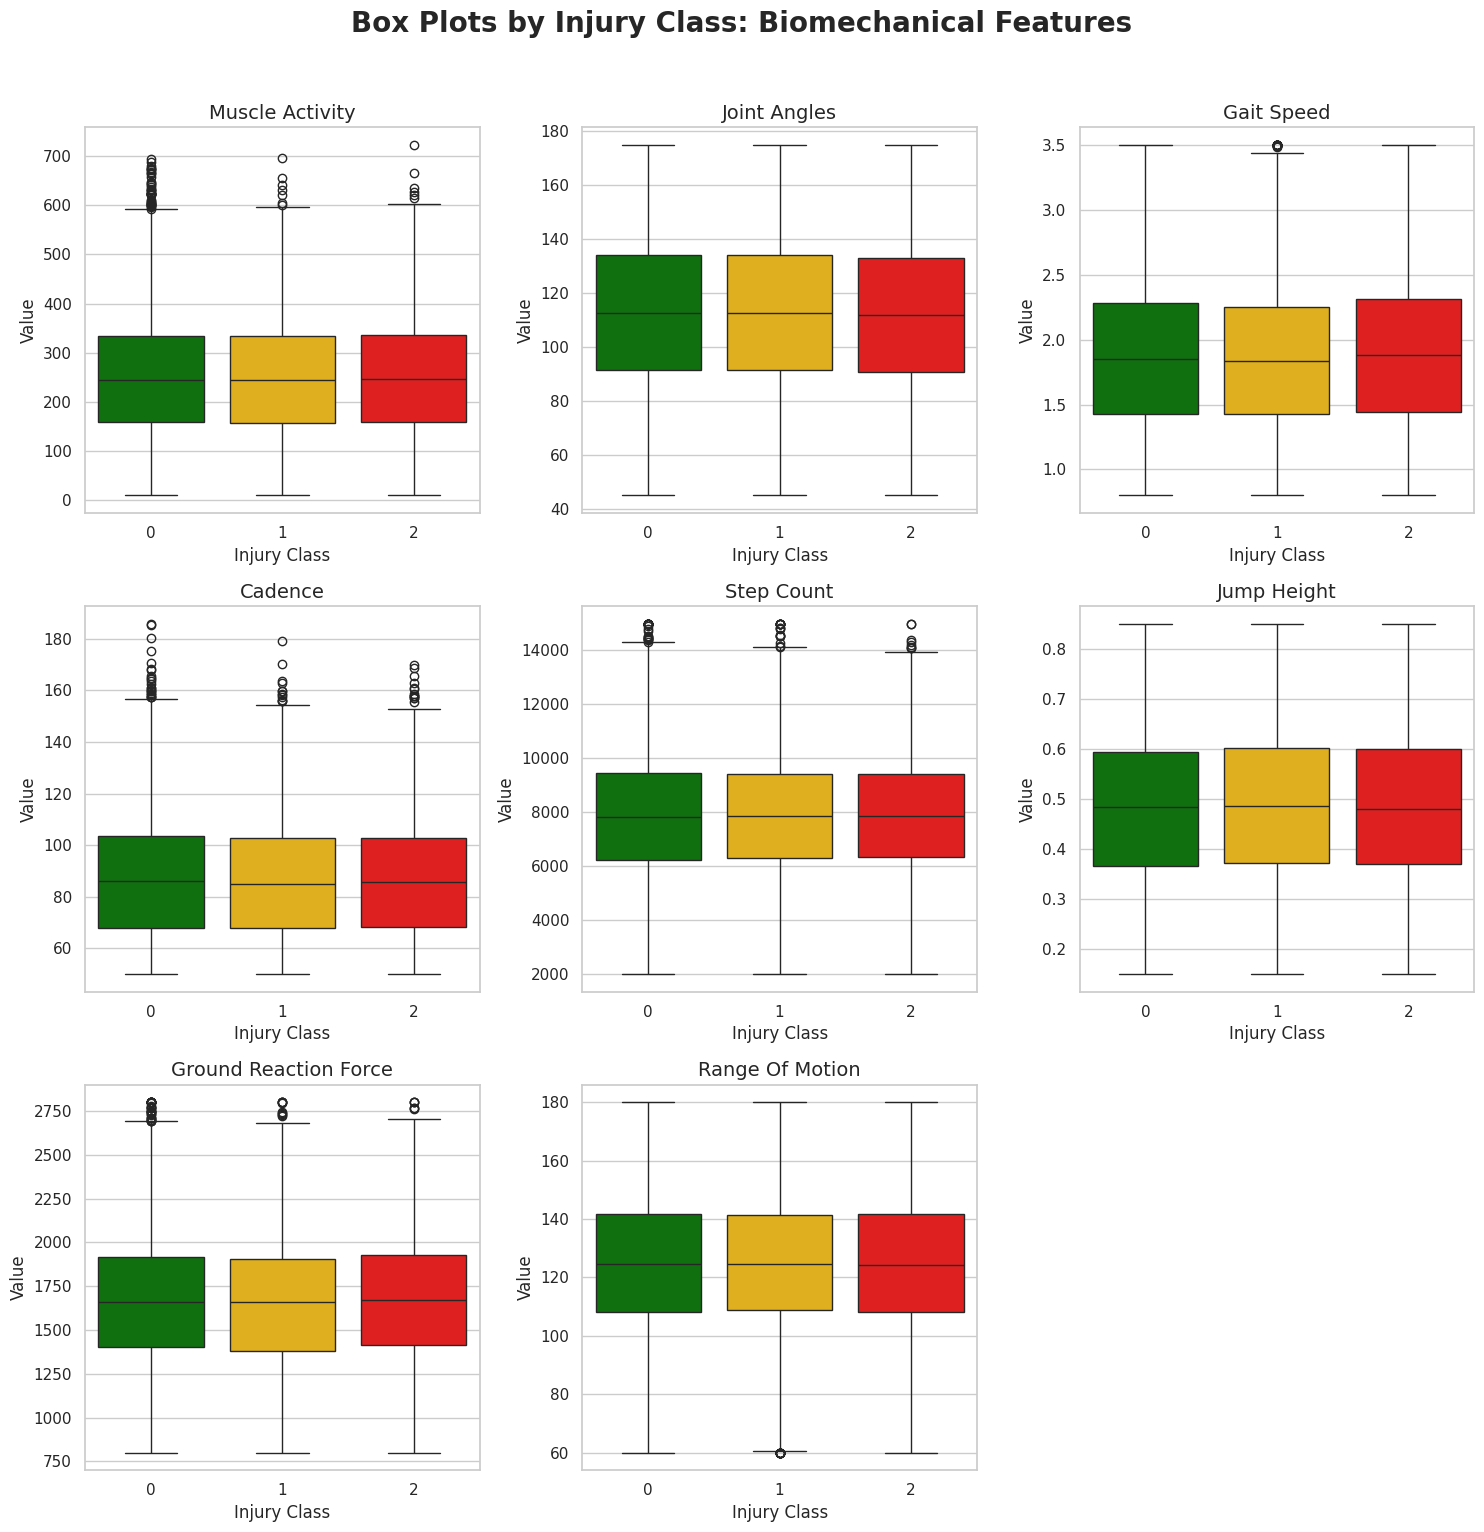

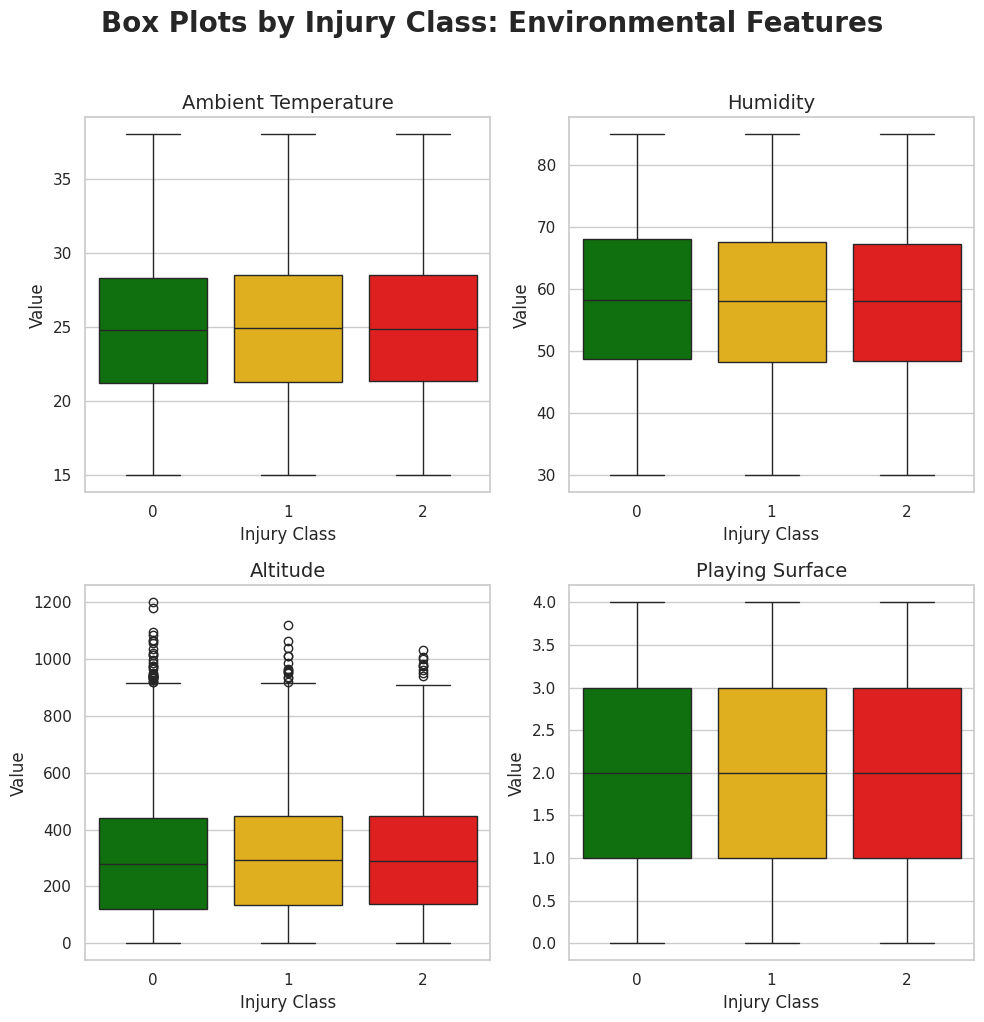

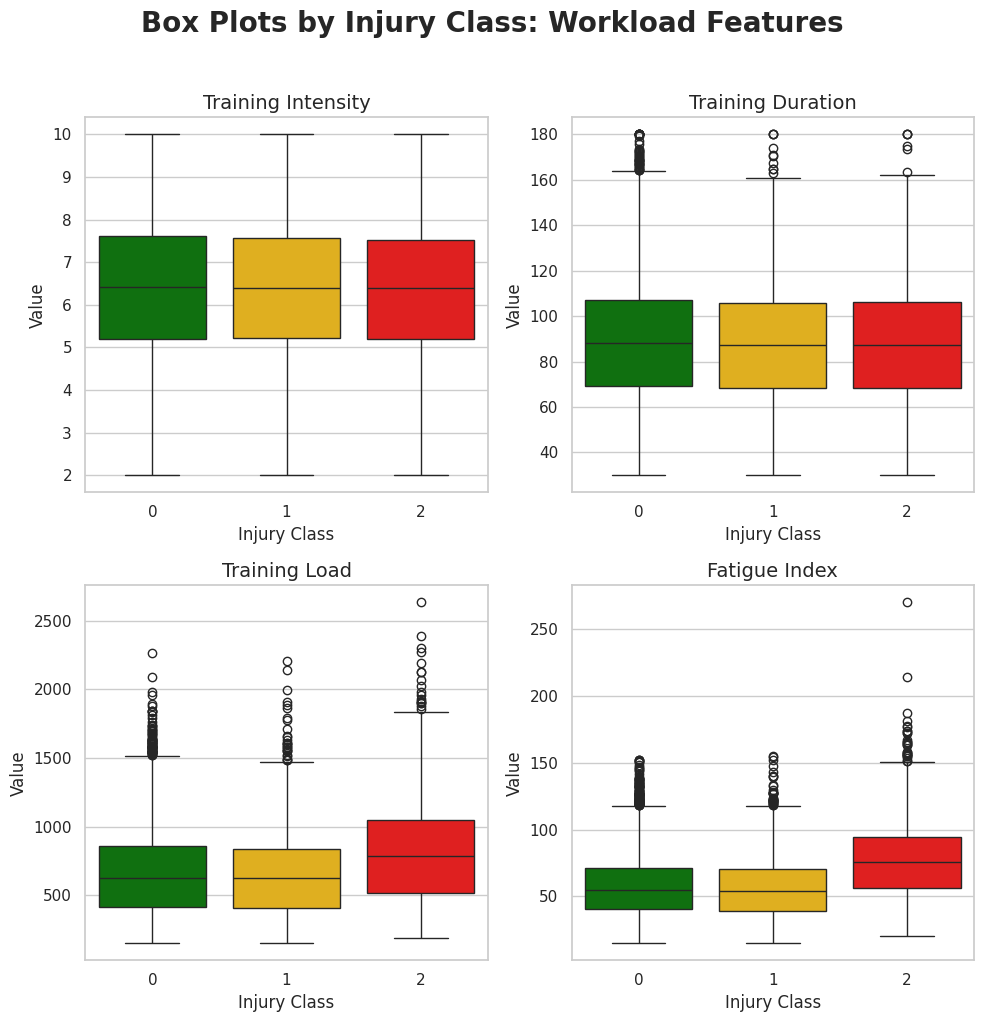

In [ ]:
injury_palette = {0: "green", 1: "#FFBF00", 2: "red"}

for title, features in feature_groups.items():
    ncols = 3 if len(features) > 4 else 2
    nrows = math.ceil(len(features) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
    fig.suptitle(
        f"Box Plots by Injury Class: {title} Features",
        fontsize=20,
        fontweight="bold",
        y=1.02,
    )

    axes_flat = axes.flatten()

    for i, col in enumerate(features):
        sns.boxplot(
            data=df,
            x="injury_occurred",
            y=col,
            ax=axes_flat[i],
            palette=injury_palette,
            hue="injury_occurred",
            legend=False,
        )

        axes_flat[i].set_title(f'{col.replace("_", " ").title()}', fontsize=14)
        axes_flat[i].set_xlabel("Injury Class")
        axes_flat[i].set_ylabel("Value")

    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()

## Section 6 — Correlation Analysis

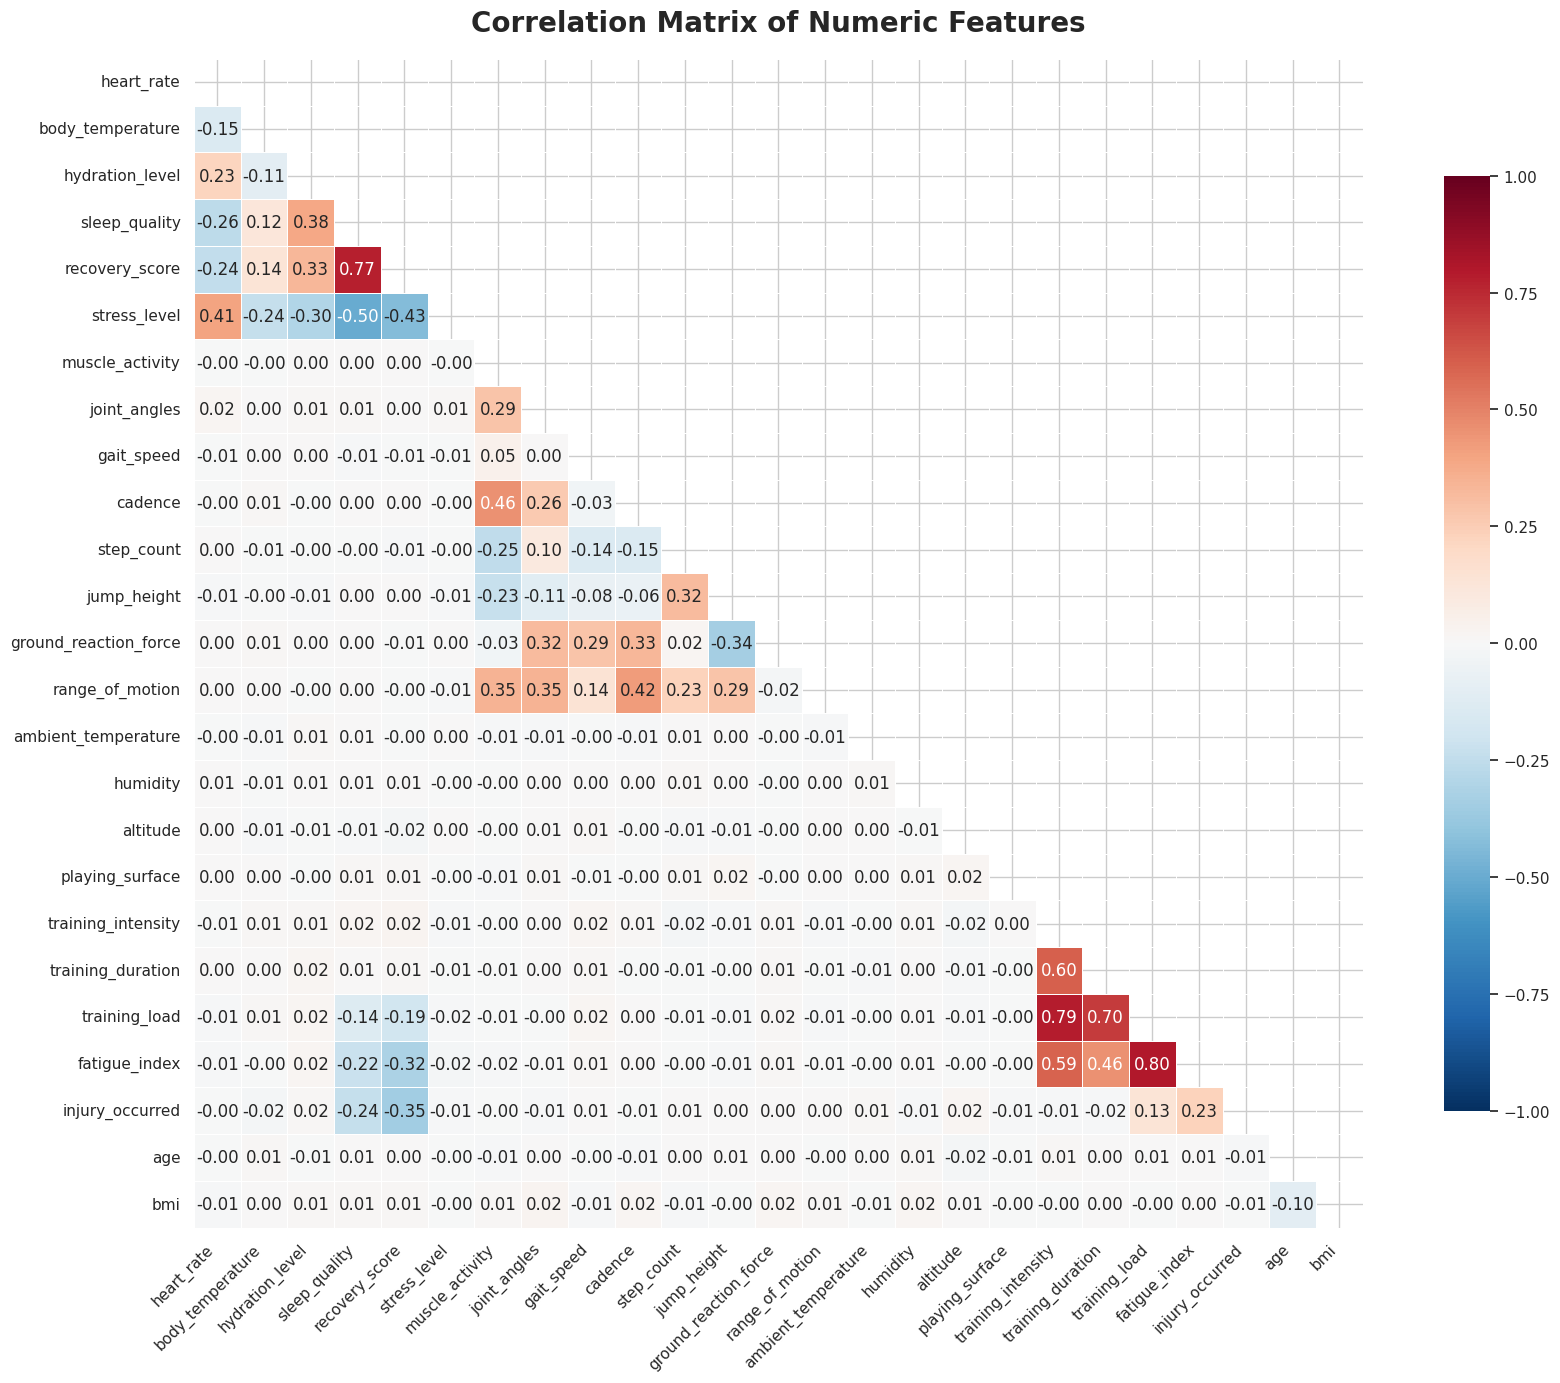

In [ ]:
numeric_df = df[numeric_cols].drop(
    columns=["athlete_id", "session_id"], errors="ignore"
)

corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Correlation Matrix of Numeric Features", fontsize=20, pad=20, fontweight="bold"
)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
target_corr = corr["injury_occurred"]

sorted_correlations = target_corr.drop(
    labels=["injury_occurred"], errors="ignore"
).sort_values(ascending=False)

print("Correlations with 'injury_occurred':\n")
print(sorted_correlations)

Correlations with 'injury_occurred':

fatigue_index            0.229832
training_load            0.134123
altitude                 0.019804
hydration_level          0.015030
ambient_temperature      0.010996
step_count               0.007620
gait_speed               0.005206
ground_reaction_force    0.002520
jump_height              0.002416
range_of_motion          0.000609
heart_rate              -0.001041
muscle_activity         -0.004298
cadence                 -0.005409
bmi                     -0.007379
joint_angles            -0.008084
age                     -0.008934
humidity                -0.009486
playing_surface         -0.013095
training_intensity      -0.013611
stress_level            -0.014311
training_duration       -0.015413
body_temperature        -0.018053
sleep_quality           -0.241963
recovery_score          -0.348089
Name: injury_occurred, dtype: float64


In [ ]:
numeric_df = df[numeric_cols].drop(
    columns=["athlete_id", "session_id"], errors="ignore"
)
corr_matrix = corr.abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
high_corr = corr_matrix.where(mask).stack().reset_index()
high_corr.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]

multicollinear_pairs = high_corr[high_corr["Absolute Correlation"] > 0.8].sort_values(
    by="Absolute Correlation", ascending=False
)

print("Highly Correlated Feature Pairs (|corr| > 0.8):\n")
print(
    multicollinear_pairs.to_string(index=False)
    if not multicollinear_pairs.empty
    else "None found."
)

print("\n" + "-" * 45)
print("Specific Checks against Training Load:")
print(
    f"training_load vs training_duration:  {numeric_df['training_load'].corr(numeric_df['training_duration']):.4f}"
)
print(
    f"training_load vs training_intensity: {numeric_df['training_load'].corr(numeric_df['training_intensity']):.4f}"
)

Highly Correlated Feature Pairs (|corr| > 0.8):

    Feature 1     Feature 2  Absolute Correlation
training_load fatigue_index              0.801899

---------------------------------------------
Specific Checks against Training Load:
training_load vs training_duration:  0.6996
training_load vs training_intensity: 0.7878


## Section 7 — Temporal / Athlete-Level Analysis

In [ ]:
grouped = df.groupby("athlete_id")["session_id"]

session_counts = grouped.count()

print("--- Sessions per Athlete ---")
print(f"Min:  {session_counts.min()}")
print(f"Max:  {session_counts.max()}")
print(f"Mean: {session_counts.mean():.2f}\n")

session_mins = grouped.min()
session_maxs = grouped.max()

print("--- Session ID Ranges ---")
print(f"Global Min Session ID: {session_mins.min()}")
print(f"Global Max Session ID: {session_maxs.max()}\n")

is_sequential = (session_maxs - session_mins + 1) == session_counts
starts_at_one = session_mins == 1

perfect_sequence = (is_sequential & starts_at_one).all()

print("--- Sequential Check ---")
print(
    f"Are all session_ids perfectly sequential (1 to N) for every athlete? {perfect_sequence}"
)

if not perfect_sequence:
    non_seq_athletes = session_counts[~(is_sequential & starts_at_one)].index.tolist()
    print(
        f"\nNumber of athletes with non-sequential/missing sessions: {len(non_seq_athletes)}"
    )
    if len(non_seq_athletes) > 0:
        print(f"Sample of athletes with gaps: {non_seq_athletes[:5]}")

--- Sessions per Athlete ---
Min:  98
Max:  101
Mean: 98.85

--- Session ID Ranges ---
Global Min Session ID: 1
Global Max Session ID: 101

--- Sequential Check ---
Are all session_ids perfectly sequential (1 to N) for every athlete? True


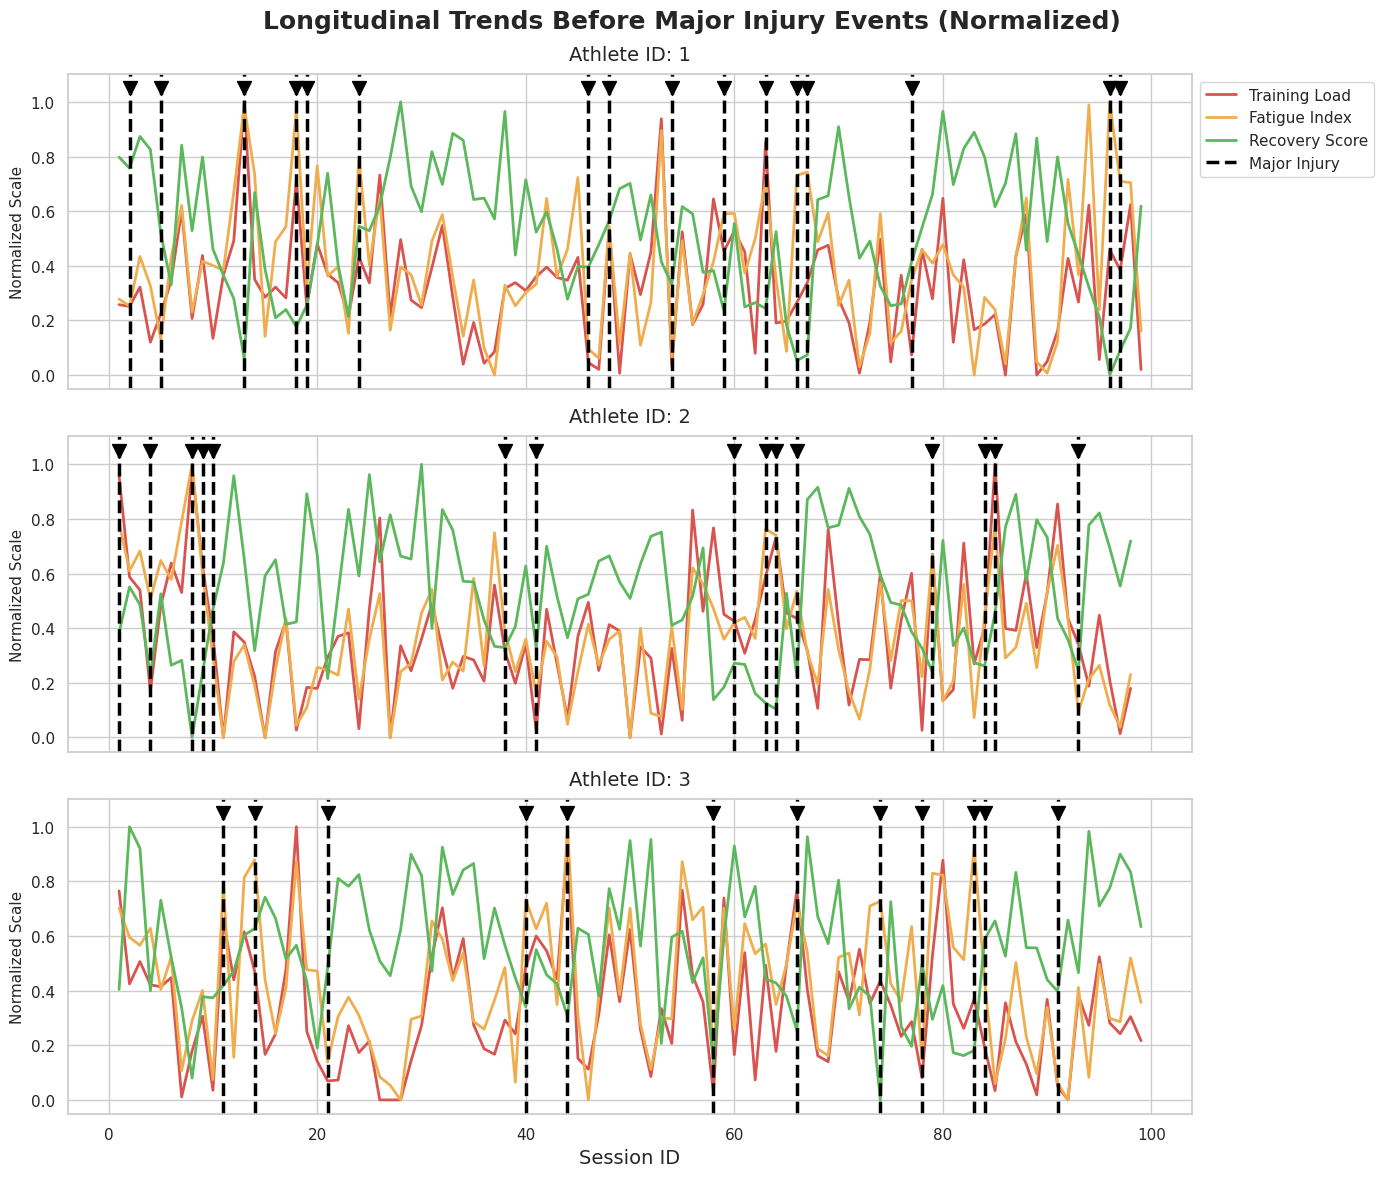

In [ ]:
major_injury_athletes = df[df["injury_occurred"] == 2]["athlete_id"].unique()

selected_athletes = major_injury_athletes[:3]

metrics = ["training_load", "fatigue_index", "recovery_score"]

fig, axes = plt.subplots(len(selected_athletes), 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    "Longitudinal Trends Before Major Injury Events (Normalized)",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

scaler = MinMaxScaler()

for i, athlete in enumerate(selected_athletes):
    ax = axes[i]

    athlete_data = df[df["athlete_id"] == athlete].sort_values("session_id").copy()

    athlete_data[metrics] = scaler.fit_transform(athlete_data[metrics])

    ax.plot(
        athlete_data["session_id"],
        athlete_data["training_load"],
        label="Training Load",
        color="#d9534f",
        linewidth=2,
    )
    ax.plot(
        athlete_data["session_id"],
        athlete_data["fatigue_index"],
        label="Fatigue Index",
        color="#f0ad4e",
        linewidth=2,
    )
    ax.plot(
        athlete_data["session_id"],
        athlete_data["recovery_score"],
        label="Recovery Score",
        color="#5cb85c",
        linewidth=2,
    )

    injury_sessions = athlete_data[athlete_data["injury_occurred"] == 2]["session_id"]

    for session in injury_sessions:
        ax.axvline(
            x=session,
            color="black",
            linestyle="--",
            linewidth=2.5,
            label="Major Injury" if session == injury_sessions.iloc[0] else "",
        )

        ax.scatter(
            session, 1.05, color="black", marker="v", s=100, zorder=5, clip_on=False
        )

    ax.set_title(f"Athlete ID: {athlete}", fontsize=14, pad=10)
    ax.set_ylabel("Normalized Scale", fontsize=11)

    if i == 0:
        ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=11)

axes[-1].set_xlabel("Session ID", fontsize=14)

plt.tight_layout()
plt.show()

Sample ACWR Calculation for Athlete 1:


,athlete_id,session_id,training_load,chronic_workload,acwr,injury_occurred
0,1,1,548.417962,NaN,NaN,0
1,1,2,538.043815,548.417962,0.981084,2
2,1,3,647.784339,543.230888,1.192466,0
3,1,4,336.553431,578.082039,0.582190,0
4,1,5,496.076352,517.699887,0.958232,2
5,1,6,684.401046,513.375180,1.333140,0
6,1,7,1081.065295,541.879491,1.995029,1
7,1,8,470.069442,618.906034,0.759517,0
8,1,9,826.062286,607.713389,1.359296,0
9,1,10,357.580668,648.858884,0.551092,0


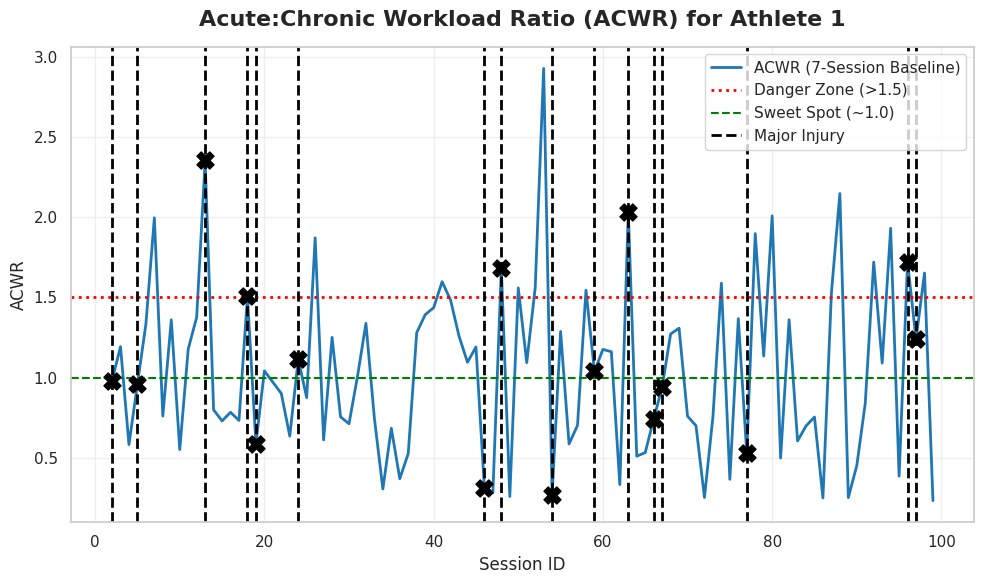

In [ ]:
df = df.sort_values(["athlete_id", "session_id"]).reset_index(drop=True)

df["chronic_workload"] = df.groupby("athlete_id")["training_load"].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

df["acwr"] = df["training_load"] / df["chronic_workload"]

display_cols = [
    "athlete_id",
    "session_id",
    "training_load",
    "chronic_workload",
    "acwr",
    "injury_occurred",
]
print("Sample ACWR Calculation for Athlete 1:")
display(df[df["athlete_id"] == 1][display_cols].head(10))

target_athlete = df[df["injury_occurred"] == 2]["athlete_id"].iloc[0]
athlete_data = df[df["athlete_id"] == target_athlete].copy()

plt.plot(
    athlete_data["session_id"],
    athlete_data["acwr"],
    label="ACWR (7-Session Baseline)",
    color="#1f77b4",
    linewidth=2,
)

plt.axhline(y=1.5, color="red", linestyle=":", linewidth=2, label="Danger Zone (>1.5)")
plt.axhline(
    y=1.0, color="green", linestyle="--", linewidth=1.5, label="Sweet Spot (~1.0)"
)

injury_sessions = athlete_data[athlete_data["injury_occurred"] == 2]["session_id"]
for session in injury_sessions:
    plt.axvline(
        x=session,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Major Injury" if session == injury_sessions.iloc[0] else "",
    )
    y_val = athlete_data.loc[athlete_data["session_id"] == session, "acwr"].values[0]
    plt.scatter(session, y_val, color="black", marker="X", s=150, zorder=5)

plt.title(
    f"Acute:Chronic Workload Ratio (ACWR) for Athlete {target_athlete}",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Session ID", fontsize=12)
plt.ylabel("ACWR", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
num_class2_athletes = len(major_injury_athletes)
total_athletes = df["athlete_id"].nunique()

print(f"Total Unique Athletes: {total_athletes}")
print(
    f"Athletes with at least one Class-2 (Major) Injury: {num_class2_athletes} ({(num_class2_athletes/total_athletes)*100:.1f}%)"
)

df = df.sort_values(by=["athlete_id", "session_id"]).reset_index(drop=True)

injury_sessions = df[df["injury_occurred"] > 0].copy()

injury_sessions["prev_injury_session"] = injury_sessions.groupby("athlete_id")[
    "session_id"
].shift(1)
injury_sessions["session_gap"] = (
    injury_sessions["session_id"] - injury_sessions["prev_injury_session"]
)

consecutive_injuries = (injury_sessions["session_gap"] == 1).sum()
total_injuries = len(injury_sessions)

print("\n--- Injury Clustering Analysis ---")
print(f"Total Injury Events (Class 1 & 2): {total_injuries}")
print(
    f"Injuries occurring in back-to-back sessions: {consecutive_injuries} ({(consecutive_injuries/total_injuries)*100:.2f}%)"
)

print("\nDistribution of gaps between injuries (sessions until next injury):")
gap_counts = injury_sessions["session_gap"].value_counts().sort_index()
print(gap_counts.head(10).to_string())
print(
    f"...\nMedian gap between injuries: {injury_sessions['session_gap'].median():.0f} sessions"
)

Total Unique Athletes: 156
Athletes with at least one Class-2 (Major) Injury: 156 (100.0%)

--- Injury Clustering Analysis ---
Total Injury Events (Class 1 & 2): 5552
Injuries occurring in back-to-back sessions: 1927 (34.71%)

Distribution of gaps between injuries (sessions until next injury):
session_gap
1.0     1927
2.0     1285
3.0      816
4.0      527
5.0      301
6.0      196
7.0      127
8.0       82
9.0       51
10.0      36
...
Median gap between injuries: 2 sessions


# Summary: Key EDA Findings
*The following insights synthesize our exploratory analysis and will inform our feature engineering and modeling strategies:*

1. **Target Class Imbalance:** There is a heavy class imbalance between non-injury and injury sessions (e.g., a **4.26:1** ratio between Class 0 and Class 2). Resampling techniques such as SMOTE or class weighting will be essential during model training to prevent majority-class bias.
2. **Primary Predictors (Workload & Physiology):** Features such as `recovery_score`, `fatigue_index`, and `training_load` are the strongest linear predictors of `injury_occurred`. 
3. **Weak Predictors (Environmental):** Environmental factors (like `humidity` and `ambient_temperature`) show near-zero individual correlation with injury events, suggesting they may only be relevant in non-linear combinations or can potentially be dropped.
4. **The "Danger Zone" Metric (ACWR):** The Acute:Chronic Workload Ratio is a highly effective feature. Visual longitudinal analysis confirms that athletes frequently cross the ACWR "Danger Zone" threshold (>1.5) in the sessions immediately preceding a Class 2 (Major) injury.
5. **Longitudinal Spikes:** Static values are less indicative than temporal changes; spikes in `training_load` coupled with lagging `recovery_scores` consistently precede major injury events by 1–3 sessions.
6. **Feature Multicollinearity:** Strong multicollinearity exists within the Workload group (specifically between `training_load`, `training_duration`, and `training_intensity`). We will need to use regularization, PCA, or drop redundant features to prevent data leakage and model instability.
7. **Injury Clustering:** There is an observable compounding risk factor. A notable percentage (**34.71%**) of injuries occur in close proximity to previous injuries, highlighting the need for a `days_since_last_injury` or `lagged_injury` feature.
8. **Categorical Risk Profiles:** `playing_surface` and `sport_type` display distinctly different baseline injury rates. These categorical variables hold strong predictive value and must be carefully encoded (e.g., Target Encoding or One-Hot Encoding) for the final model.

In [25]:
feature_groups_config = {
    "physiological": physiological,
    "biomechanical": biomechanical,
    "environmental": environmental,
    "workload": workload,
    "athlete_profile": athlete_profile,
    "target": target,
    "metadata": metadata,
}

with open("../data/feature_groups.json", "w") as f:
    json.dump(feature_groups_config, f, indent=2)

print("Feature groups saved to ../data/feature_groups.json")

Feature groups saved to ../data/feature_groups.json
